In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('auto-mpg.csv')

data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
# Ada nilai "?" pada field horsepower
data[data['horsepower']=='?']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,?,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,?,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,?,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,?,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,?,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,?,3035,20.5,82,1,amc concord dl


In [4]:
# Hapus nilai "?"
data = data.replace('?', np.nan) # Ganti "?" jadi "NaN"

data.dropna(subset=['horsepower'], inplace=True) # Hapus "NaN"

In [5]:
# Pisahkan car name ke brand
list_brand=[]

for i in data.index:
    list_brand.append(data["car name"][i].split(" ")[0])

In [6]:
data['brand']=list_brand

In [7]:
# Normalisasi brand
data['brand'] = data['brand'].replace(['volkswagen','vokswagen','vw'],'volkswagen')
data['brand'] = data['brand'].replace('maxda','mazda')
data['brand'] = data['brand'].replace('toyouta','toyota')
data['brand'] = data['brand'].replace('mercedes-benz','mercedes')
data['brand'] = data['brand'].replace('nissan','datsun')
data['brand'] = data['brand'].replace('capri','ford')
data['brand'] = data['brand'].replace(['chevroelt','chevy'],'chevrolet')

In [8]:
data['brand'].value_counts()

brand
ford          49
chevrolet     47
plymouth      31
dodge         28
amc           27
toyota        26
datsun        24
volkswagen    22
buick         17
pontiac       16
honda         13
mazda         12
mercury       11
oldsmobile    10
fiat           8
peugeot        8
audi           7
volvo          6
chrysler       6
saab           4
opel           4
subaru         4
renault        3
mercedes       3
cadillac       2
bmw            2
hi             1
triumph        1
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_9944\2964047833.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="brand",  data=data, palette="Greens_d",


<Axes: xlabel='count', ylabel='brand'>

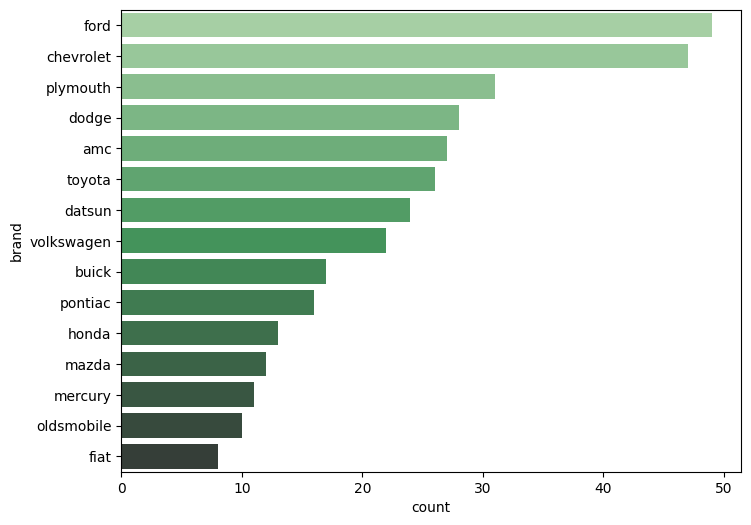

In [9]:
# Visusalisasi brand
plt.figure(figsize=(8,6))
sns.countplot(y="brand",  data=data, palette="Greens_d",
              order=data.brand.value_counts().iloc[:15].index)

In [10]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,brand
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,chevrolet
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,buick
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,plymouth
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,amc
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,ford


In [11]:
# Convert Cu ke Cc
data['displacement_in_cc']=data['displacement']*16.387 

In [12]:
# Convert lbs ke Kg
data['weight_in_kg']=data['weight']/2.205 

In [13]:
# Convert Mpg ke Kpl
data['mileage_kpl']=data['mpg']/2.352  

In [14]:
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name,brand,displacement_in_cc,weight_in_kg,mileage_kpl
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,chevrolet,5030.809,1589.115646,7.653061
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,buick,5735.450,1674.829932,6.377551
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,plymouth,5211.066,1558.276644,7.653061
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,amc,4981.648,1556.916100,6.802721
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,ford,4948.874,1564.172336,7.227891


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   mpg                 392 non-null    float64
 1   cylinders           392 non-null    int64  
 2   displacement        392 non-null    float64
 3   horsepower          392 non-null    object 
 4   weight              392 non-null    int64  
 5   acceleration        392 non-null    float64
 6   model year          392 non-null    int64  
 7   origin              392 non-null    int64  
 8   car name            392 non-null    object 
 9   brand               392 non-null    object 
 10  displacement_in_cc  392 non-null    float64
 11  weight_in_kg        392 non-null    float64
 12  mileage_kpl         392 non-null    float64
dtypes: float64(6), int64(4), object(3)
memory usage: 51.0+ KB


In [16]:
data['horsepower']=data['horsepower'].astype(int)

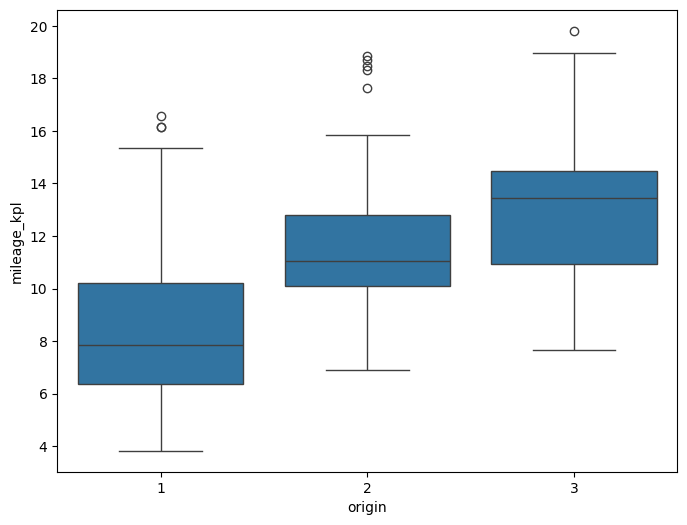

In [17]:
#origin and performance
plt.figure(figsize=(8,6))
sns.boxplot(x=data['origin'],y=data['mileage_kpl']);

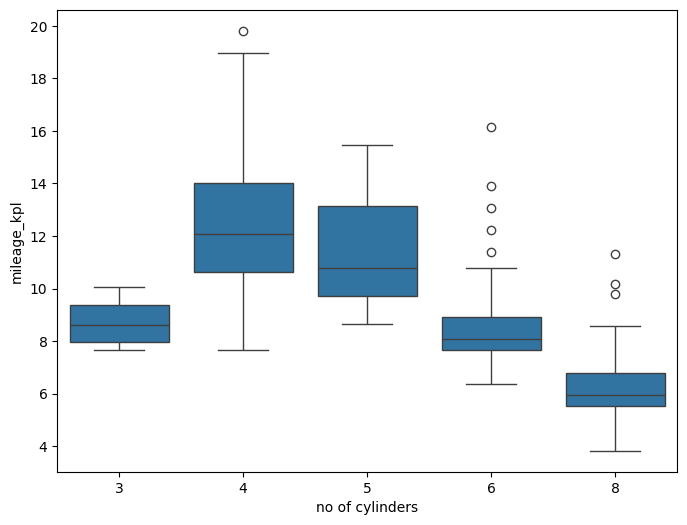

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(y=data['mileage_kpl'],x=data['cylinders'])
plt.xlabel("no of cylinders");

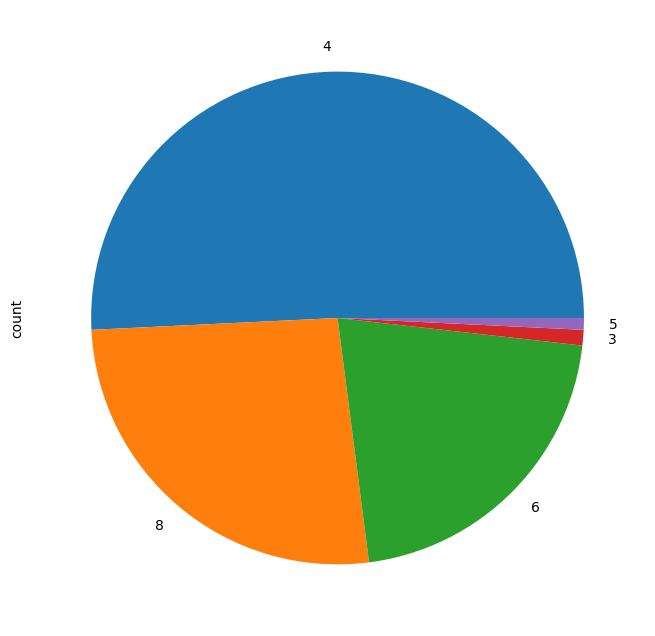

In [19]:
# Chart field cylinder
plt.figure(figsize=(14,8))
data.cylinders.value_counts().plot(kind='pie');

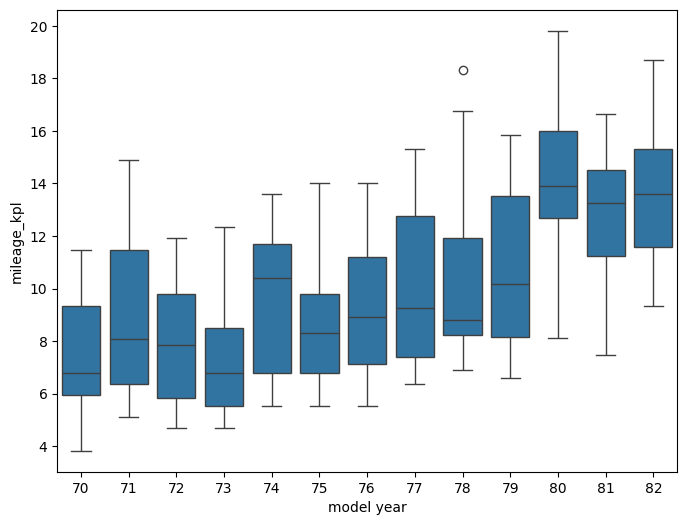

In [20]:
# Performance over years
plt.figure(figsize=(8,6))
sns.boxplot(x=data['model year'],y=data['mileage_kpl']);

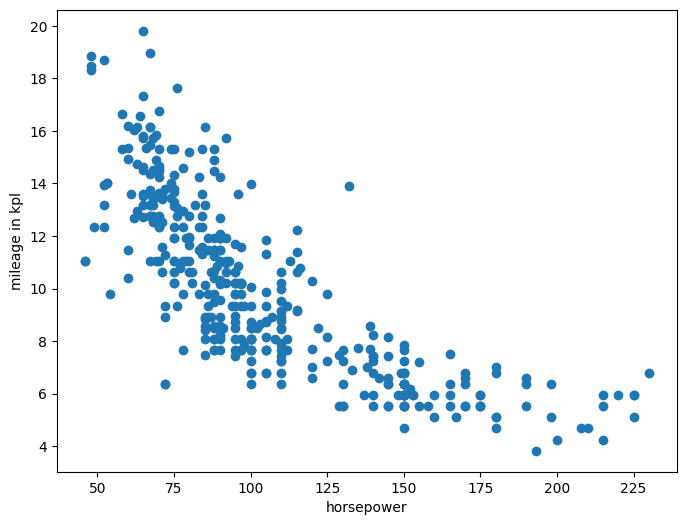

In [21]:
# Horsepower and mileage_kpl
plt.figure(figsize=(8,6))
plt.scatter(data.horsepower,data.mileage_kpl)
plt.xlabel('horsepower')
plt.ylabel('mileage in kpl');

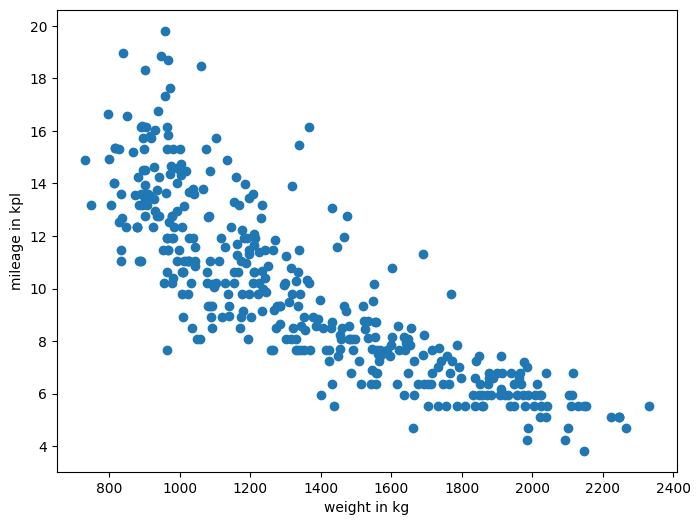

In [22]:
# Weight and mileage
plt.figure(figsize=(8,6))
plt.scatter(data.weight_in_kg,data.mileage_kpl)
plt.xlabel('weight in kg')
plt.ylabel('mileage in kpl');

In [23]:
# Drop field yang tidak digunakan
X=data.drop(['displacement','weight','car name','brand','mpg'],axis=1)

In [24]:
X.head()

,cylinders,horsepower,acceleration,model year,origin,displacement_in_cc,weight_in_kg,mileage_kpl
0,8,130,12.0,70,1,5030.809,1589.115646,7.653061
1,8,165,11.5,70,1,5735.450,1674.829932,6.377551
2,8,150,11.0,70,1,5211.066,1558.276644,7.653061
3,8,150,12.0,70,1,4981.648,1556.916100,6.802721
4,8,140,10.5,70,1,4948.874,1564.172336,7.227891


In [25]:
X.corr()

,cylinders,horsepower,acceleration,model year,origin,displacement_in_cc,weight_in_kg,mileage_kpl
cylinders,1.000000,0.842983,-0.504683,-0.345647,-0.568932,0.950823,0.897527,-0.777618
horsepower,0.842983,1.000000,-0.689196,-0.416361,-0.455171,0.897257,0.864538,-0.778427
acceleration,-0.504683,-0.689196,1.000000,0.290316,0.212746,-0.543800,-0.416839,0.423329
model year,-0.345647,-0.416361,0.290316,1.000000,0.181528,-0.369855,-0.309120,0.580541
origin,-0.568932,-0.455171,0.212746,0.181528,1.000000,-0.614535,-0.585005,0.565209
displacement_in_cc,0.950823,0.897257,-0.543800,-0.369855,-0.614535,1.000000,0.932994,-0.805127
weight_in_kg,0.897527,0.864538,-0.416839,-0.309120,-0.585005,0.932994,1.000000,-0.832244
mileage_kpl,-0.777618,-0.778427,0.423329,0.580541,0.565209,-0.805127,-0.832244,1.000000


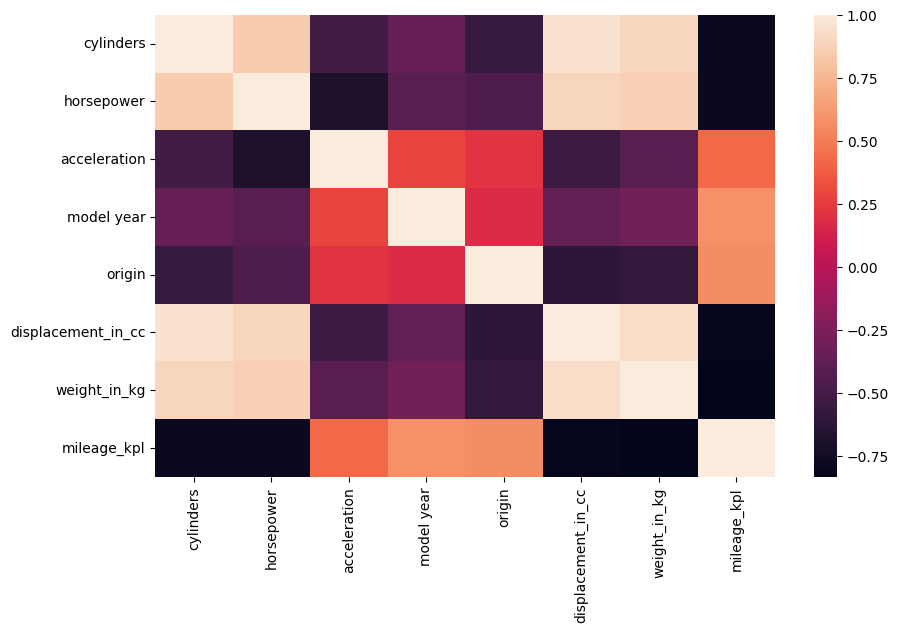

In [26]:
#plot heatmap

plt.figure(figsize=(10,6))
sns.heatmap(X.corr());

In [27]:
print(X.corr()["mileage_kpl"].sort_values(ascending=False))

mileage_kpl           1.000000
model year            0.580541
origin                0.565209
acceleration          0.423329
cylinders            -0.777618
horsepower           -0.778427
displacement_in_cc   -0.805127
weight_in_kg         -0.832244
Name: mileage_kpl, dtype: float64


In [28]:
X.head()

,cylinders,horsepower,acceleration,model year,origin,displacement_in_cc,weight_in_kg,mileage_kpl
0,8,130,12.0,70,1,5030.809,1589.115646,7.653061
1,8,165,11.5,70,1,5735.450,1674.829932,6.377551
2,8,150,11.0,70,1,5211.066,1558.276644,7.653061
3,8,150,12.0,70,1,4981.648,1556.916100,6.802721
4,8,140,10.5,70,1,4948.874,1564.172336,7.227891


In [29]:
y=X['mileage_kpl']

In [30]:
X=X.drop(['mileage_kpl'],axis=1)

In [31]:
X.head()

,cylinders,horsepower,acceleration,model year,origin,displacement_in_cc,weight_in_kg
0,8,130,12.0,70,1,5030.809,1589.115646
1,8,165,11.5,70,1,5735.450,1674.829932
2,8,150,11.0,70,1,5211.066,1558.276644
3,8,150,12.0,70,1,4981.648,1556.916100
4,8,140,10.5,70,1,4948.874,1564.172336


In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error 
from sklearn import metrics

In [33]:
# Train model
lr=LinearRegression()

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20)

lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
y_pred=lr.predict(X_test)

In [35]:
lr.score(X_test,y_test)

0.8309981506107192

In [41]:
lr.predict([[4,120,9.7,90,3,1497,1160]])

C:\Users\User\anaconda3\envs\ai_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([15.46557205])

In [43]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_rf))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_rf))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf)))
print('R2 Score:', metrics.r2_score(y_test, y_pred))

Mean Absolute Error: 0.8825023680358216
Mean Squared Error: 1.5988058370252423
Root Mean Squared Error: 1.264438941596328
R2 Score: 0.8309981506107192
